# <p style="background-color:#010521 ;font-family:Comic Sans MS; color:white;font-size:150%;text-align:center;border-radius:55px 1px;">STROKE PREDICTION</p>
<center>
<img style="border-radius: 50%" src="stroke.jpg" width="400" >
</center>
<br>
<br>

# Importations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action="ignore")

#### Read Data

In [2]:
myData = pd.read_csv("healthcare-dataset-stroke-data.csv")
myData

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# <p style="background-color:#010521 ;font-family:Comic Sans MS; color:white;font-size:100%;text-align:center;border-radius:55px 1px;">Preprocessing</p>

### Show The genders in the Dataset

In [3]:
unique_values = myData['gender'].unique()
print(unique_values)

['Male' 'Female' 'Other']


gender cleaning :

In [4]:
myData = myData[myData['gender'] != 'Other']
myData

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


### Show The genders in the Dataset after we deleted 'Other'

In [5]:
unique_values = myData['gender'].unique()
print(unique_values)

['Male' 'Female']


#### Filling NAN Values in the 'BMI' Columnn:

In [6]:
myData['bmi'].fillna(myData['bmi'].mean(), inplace=True)

#### Now, give every string-value an integer value :

In [7]:
myData['ever_married'] = myData['ever_married'].map({'Yes':1 ,'No':0})
myData['gender'] = myData['gender'].map({'Male':1 ,'Female':0})
myData['work_type'] = myData['work_type'].map({'Private':0 ,'Self-employed':1,'Govt_job':2,'Never_worked':3,'children':4})
myData['Residence_type'] = myData['Residence_type'].map({'Urban':1 ,'Rural':0})
myData['smoking_status'] = myData['smoking_status'].map({'never smoked':0 ,'smokes':1,'formerly smoked':2,'Unknown':3 })

#Drop the id column since it is not helpful to us:
myData.drop("id", axis = 1, inplace=True)

# Show My Data after PreProcessing:

In [8]:
myData.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,0,1,228.69,36.60000,2,1
1,0,61.0,0,0,1,1,0,202.21,28.89456,0,1
2,1,80.0,0,1,1,0,0,105.92,32.50000,0,1
3,0,49.0,0,0,1,0,1,171.23,34.40000,1,1
4,0,79.0,1,0,1,1,0,174.12,24.00000,0,1


visualization

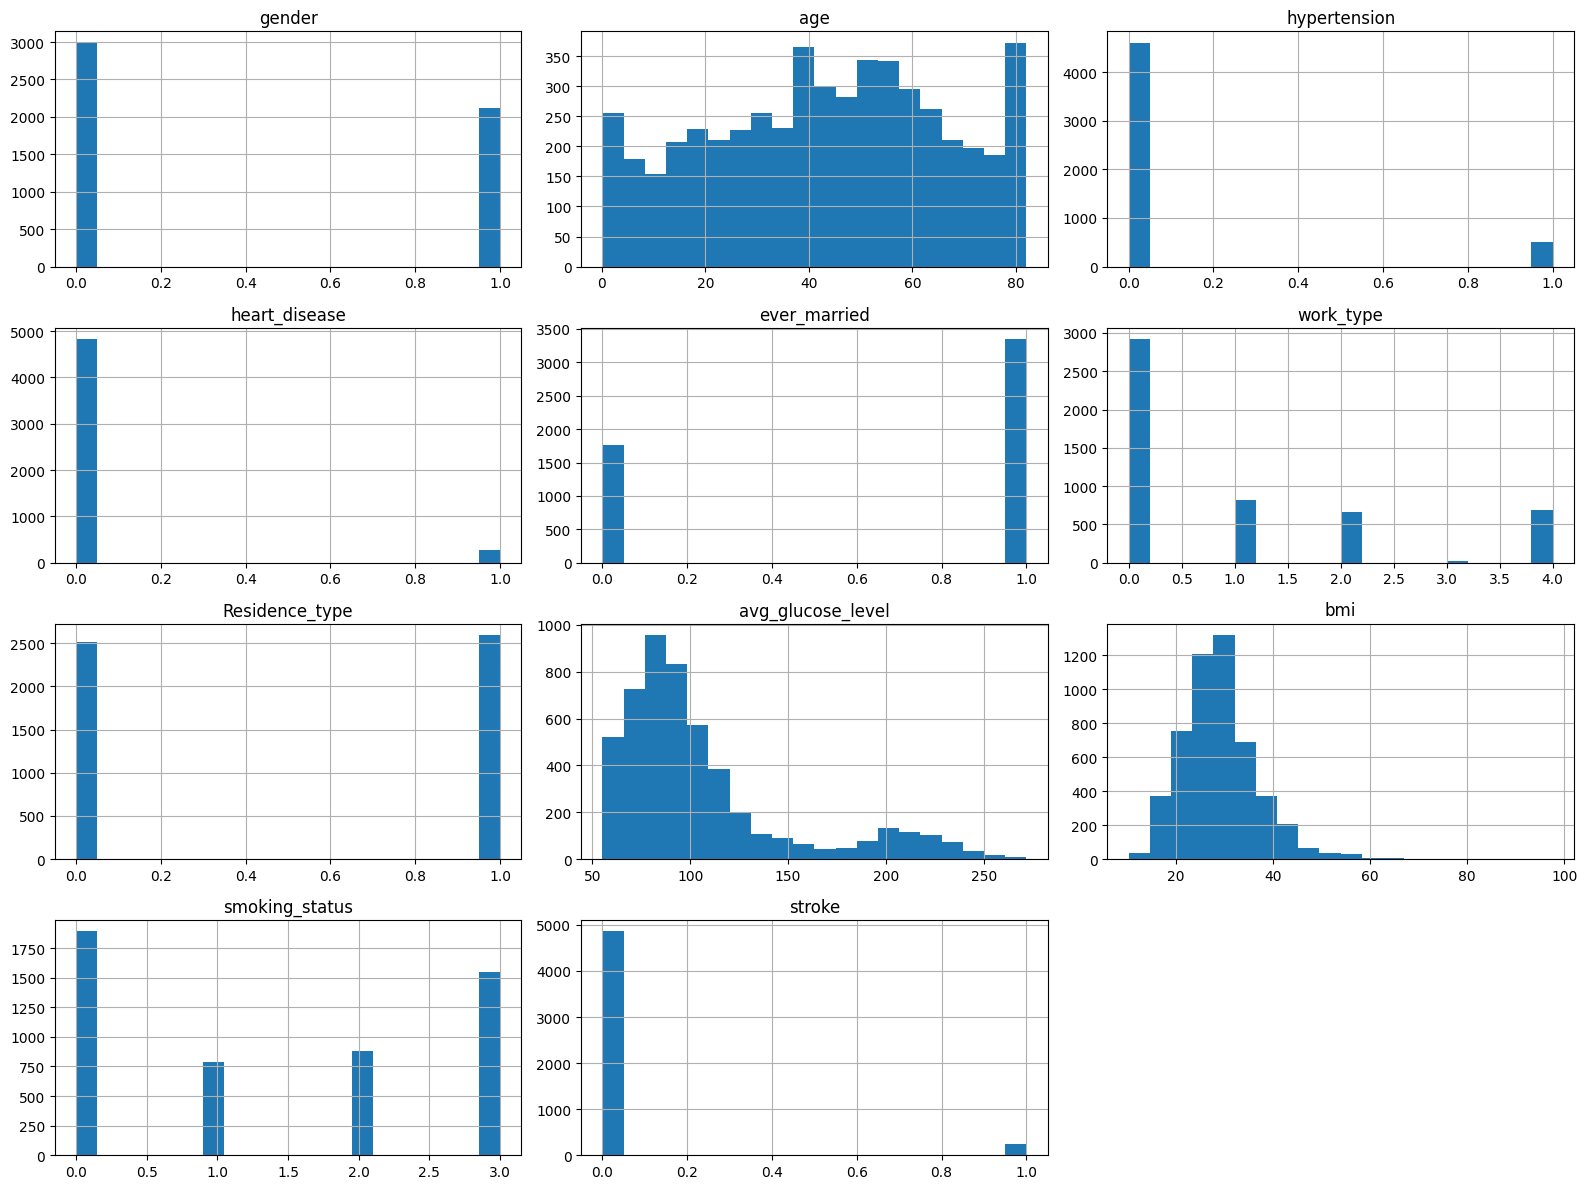

In [9]:
myData.hist(bins=20, figsize=(16, 12))
plt.tight_layout()
plt.show()

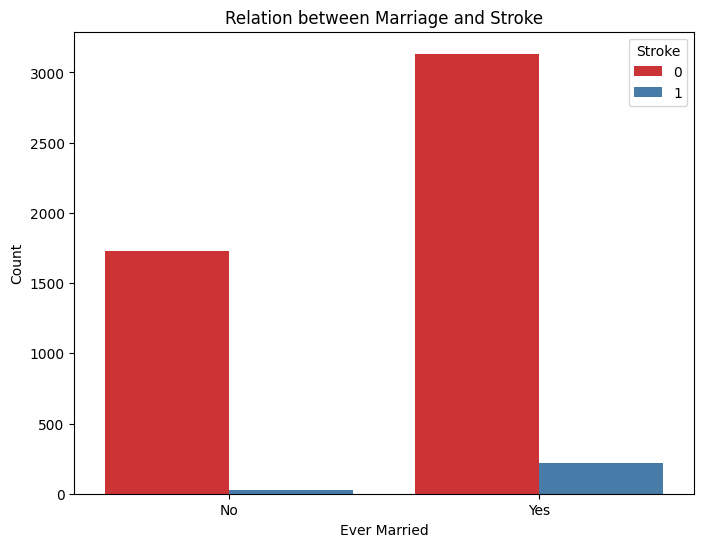

In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(x='ever_married', hue='stroke', data=myData , palette='Set1')

# Add labels and title
plt.xlabel('Ever Married')
plt.ylabel('Count')
plt.title('Relation between Marriage and Stroke')
plt.xticks([0, 1], ['No', 'Yes'])
plt.legend(title='Stroke', loc='upper right')

plt.show()

Correlation matrix

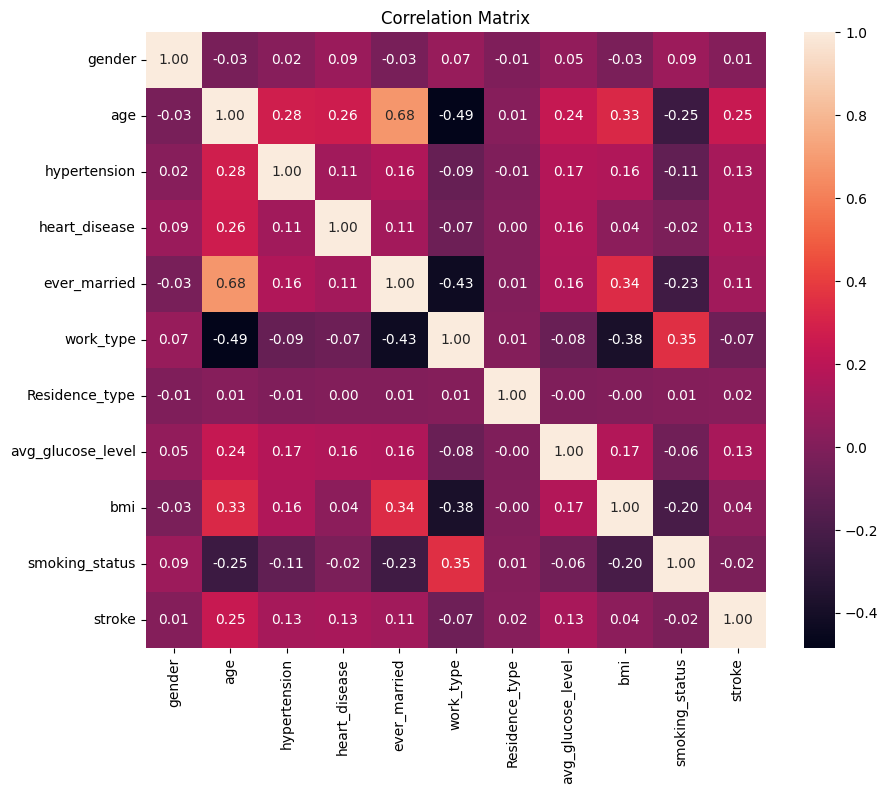

In [11]:

plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(myData, columns=myData.columns).corr(), annot=True, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

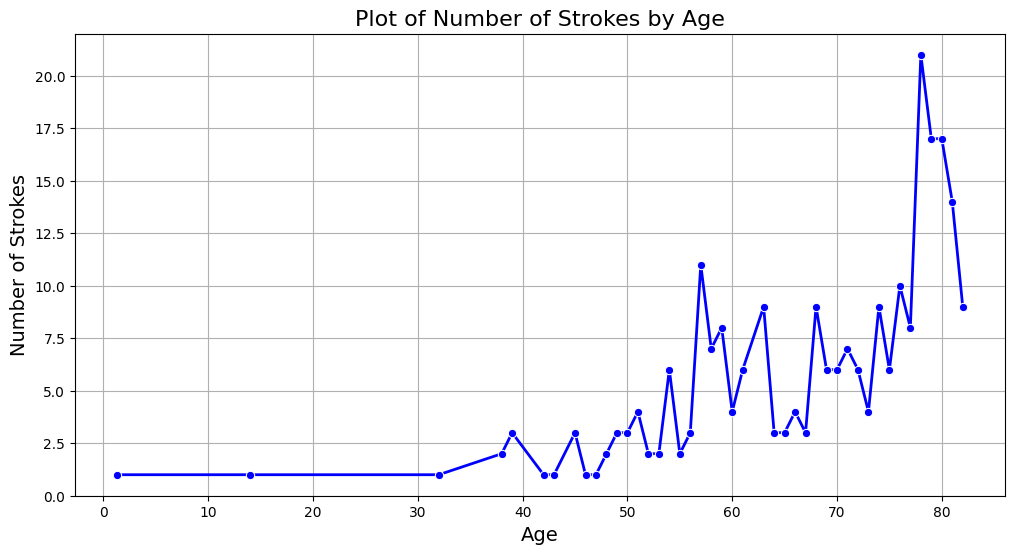

In [12]:
stroke_count_by_age = myData[myData['stroke'] == 1].groupby('age').size().reset_index(name='stroke_count')

# Sort by age for a smooth line plot
stroke_count_by_age = stroke_count_by_age.sort_values(by='age')

# Line plot with smoothing to show the number of stroked individuals by age
plt.figure(figsize=(12, 6))
sns.lineplot(data=stroke_count_by_age, x='age', y='stroke_count', marker='o', color='blue', lw=2)

# Add labels and title
plt.xlabel('Age', fontsize=14)
plt.ylabel('Number of Strokes', fontsize=14)
plt.title('Plot of Number of Strokes by Age', fontsize=16)

# Show the plot
plt.grid()
plt.show()

Boxplot

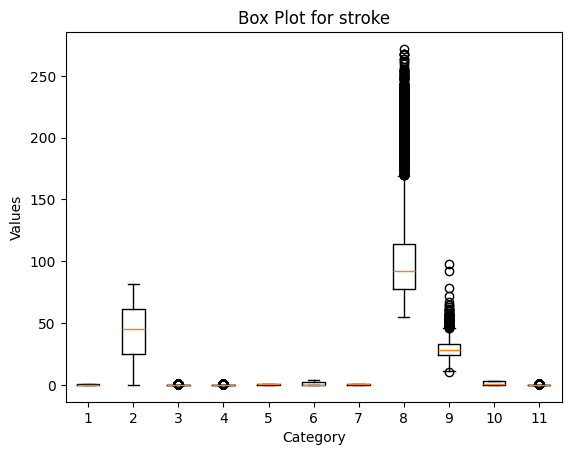

In [13]:
plt.boxplot(myData)
plt.title("Box Plot for stroke")
plt.xlabel("Category")
plt.ylabel("Values")
plt.show()

In [14]:
print(myData.head())

   gender   age  hypertension  heart_disease  ever_married  work_type  \
0       1  67.0             0              1             1          0   
1       0  61.0             0              0             1          1   
2       1  80.0             0              1             1          0   
3       0  49.0             0              0             1          0   
4       0  79.0             1              0             1          1   

   Residence_type  avg_glucose_level       bmi  smoking_status  stroke  
0               1             228.69  36.60000               2       1  
1               0             202.21  28.89456               0       1  
2               0             105.92  32.50000               0       1  
3               1             171.23  34.40000               1       1  
4               0             174.12  24.00000               0       1  


In [15]:
myData.to_csv('processed_data.csv',index=False)
print("'processed_data.csv'")

'processed_data.csv'
